In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Preprocessed ICU data.csv')
print(df.shape)

(1474, 232)


In [2]:
all_features = ['SOFA','SAPS.I',
                'Min_GCS.x', 'Max_GCS.x', 'Mean_GCS.x',
                'Min_RespRate.x', 'Max_RespRate.x', 'Mean_RespRate.x',
                'Mean_MechVent.x']
all_features_sum = df.groupby('In.hospital_death')[all_features].mean().T
all_features_sum

In.hospital_death,0,1
SOFA,6.257609,8.259928
SAPS.I,14.456522,16.572202
Min_GCS.x,9.606497,8.042845
Max_GCS.x,13.001900,11.244075
Mean_GCS.x,11.537892,9.660210
Min_RespRate.x,13.334297,13.385319
Max_RespRate.x,27.687887,27.916220
Mean_RespRate.x,19.792140,19.967495
Mean_MechVent.x,1.000000,1.000000


Direct relationship:
- SOFA and SAPS.I
  - The higher these two scores go, the sicker the patient is.
  - means that the patient's risk of dying goes up if these scores increase.

Inverse relationship:
- GCS
  - min, max and mean drop in the group of patient who died
  - Patient is less conscious or in a deeper coma when their GCS score is dropping.

Features with no relationship:
- Mean_MechVent.x
  - it returned a constant mean of exactly 1 for both the survivour and died.
  - meaning 100% of the patients received mechanical ventilation.
  - it cannot be used to predict survival outcomes

Dropping Mean_MechVent.x as it is does not help with relationship of mortality 

- RespRate.x
  - min, max and mean for this feature are almost identical between patient who survived and those who died in the hospital.
  - indicates that the linear rate of breathing does not distinguish who lives and who dies.

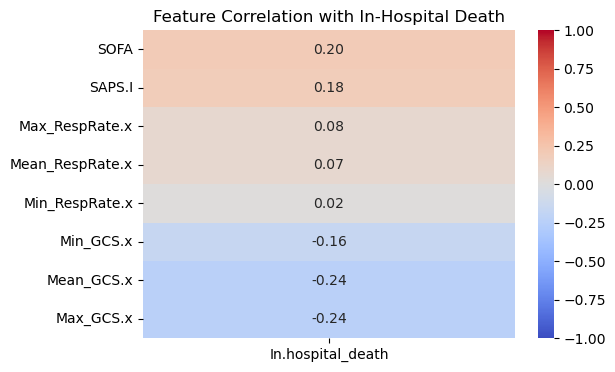

In [36]:
icu_features = ['SOFA', 'SAPS.I', 'Min_GCS.x', 'Max_GCS.x', 'Mean_GCS.x', 
                'Min_RespRate.x', 'Max_RespRate.x', 'Mean_RespRate.x', 'In.hospital_death']

death_corr = df[icu_features].corr(method = 'spearman')['In.hospital_death'].drop('In.hospital_death')

corr_df = pd.DataFrame(death_corr).sort_values(by = "In.hospital_death", ascending = False)

plt.figure(figsize = (6, 4))
sns.heatmap(corr_df, annot = True, cmap = "coolwarm", vmin = -1, vmax = 1, fmt = ".2f")
plt.title("Feature Correlation with In-Hospital Death")
plt.show()


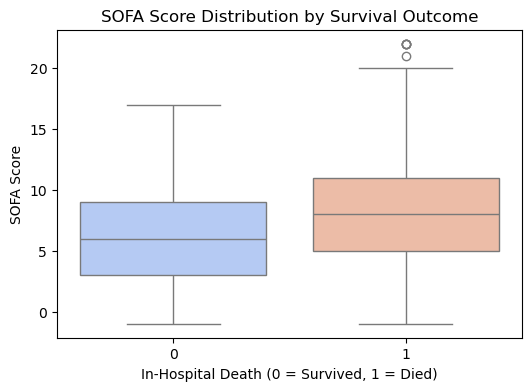

In [6]:
plt.figure(figsize=(6, 4))
sns.boxplot(data = df, x = 'In.hospital_death', y = 'SOFA', hue = 'In.hospital_death', palette = 'coolwarm', legend = False)
plt.title('SOFA Score Distribution by Survival Outcome')
plt.xlabel('In-Hospital Death (0 = Survived, 1 = Died)')
plt.ylabel('SOFA Score')
plt.show()


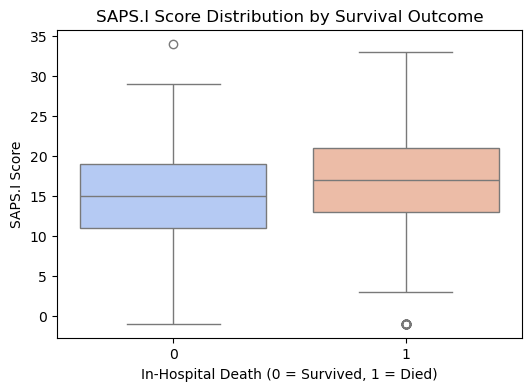

In [16]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x='In.hospital_death', y='SAPS.I', hue='In.hospital_death', palette='coolwarm', legend=False)
plt.title('SAPS.I Score Distribution by Survival Outcome')
plt.xlabel('In-Hospital Death (0 = Survived, 1 = Died)')
plt.ylabel('SAPS.I Score')
plt.show()

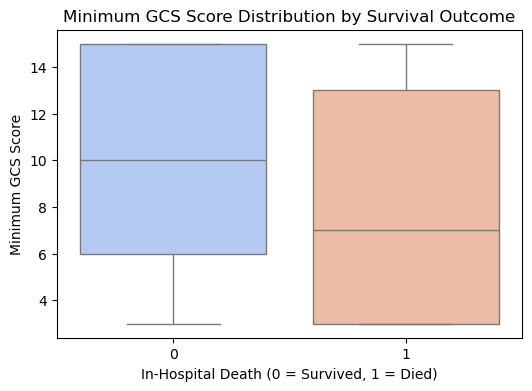

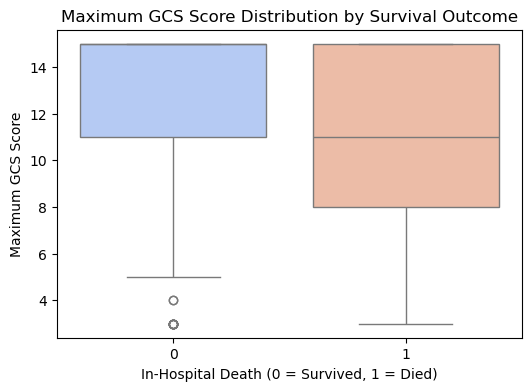

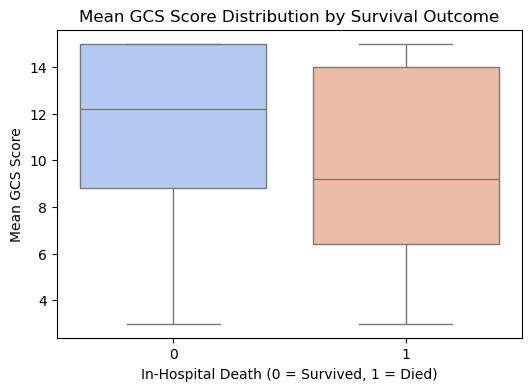

In [7]:
plt.figure(figsize=(6, 4))
sns.boxplot(data = df, x = 'In.hospital_death', y = 'Min_GCS.x', hue = 'In.hospital_death', palette = 'coolwarm', legend = False)
plt.title('Minimum GCS Score Distribution by Survival Outcome')
plt.xlabel('In-Hospital Death (0 = Survived, 1 = Died)')
plt.ylabel('Minimum GCS Score')
plt.show()

plt.figure(figsize=(6, 4))
sns.boxplot(data = df, x = 'In.hospital_death', y = 'Max_GCS.x', hue = 'In.hospital_death', palette = 'coolwarm', legend = False)
plt.title('Maximum GCS Score Distribution by Survival Outcome')
plt.xlabel('In-Hospital Death (0 = Survived, 1 = Died)')
plt.ylabel('Maximum GCS Score')
plt.show()

plt.figure(figsize=(6, 4))
sns.boxplot(data = df, x = 'In.hospital_death', y = 'Mean_GCS.x', hue = 'In.hospital_death', palette = 'coolwarm', legend = False)
plt.title('Mean GCS Score Distribution by Survival Outcome')
plt.xlabel('In-Hospital Death (0 = Survived, 1 = Died)')
plt.ylabel('Mean GCS Score')
plt.show()


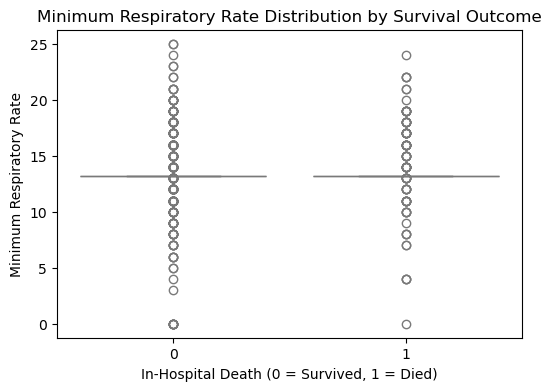

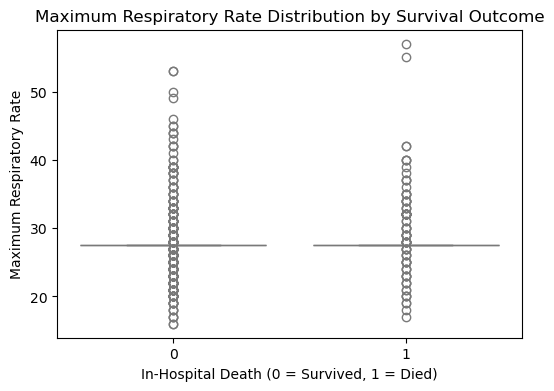

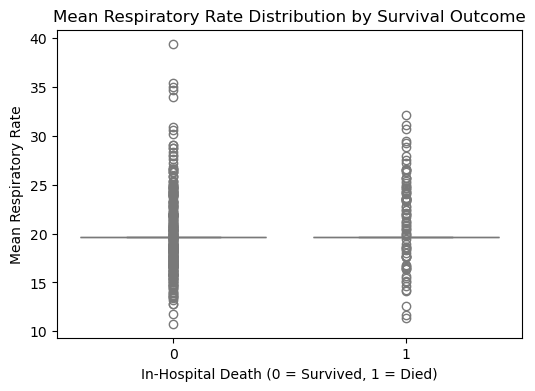

In [8]:
plt.figure(figsize=(6, 4))
sns.boxplot(data = df, x = 'In.hospital_death', y = 'Min_RespRate.x', hue = 'In.hospital_death', palette = 'coolwarm', legend = False)
plt.title('Minimum Respiratory Rate Distribution by Survival Outcome')
plt.xlabel('In-Hospital Death (0 = Survived, 1 = Died)')
plt.ylabel('Minimum Respiratory Rate')
plt.show()

plt.figure(figsize=(6, 4))
sns.boxplot(data = df, x = 'In.hospital_death', y = 'Max_RespRate.x', hue = 'In.hospital_death', palette = 'coolwarm', legend = False)
plt.title('Maximum Respiratory Rate Distribution by Survival Outcome')
plt.xlabel('In-Hospital Death (0 = Survived, 1 = Died)')
plt.ylabel('Maximum Respiratory Rate')
plt.show()

plt.figure(figsize=(6, 4))
sns.boxplot(data = df, x = 'In.hospital_death', y = 'Mean_RespRate.x', hue = 'In.hospital_death', palette = 'coolwarm', legend = False)
plt.title('Mean Respiratory Rate Distribution by Survival Outcome')
plt.xlabel('In-Hospital Death (0 = Survived, 1 = Died)')
plt.ylabel('Mean Respiratory Rate')
plt.show()

## SOFA 

(Ferreira, 2001):
- If a patient’s score crosses 11 at any point, or averages above 5 during their stay, they are in extreme danger.
- In the study, more than 80% of these patients died. If SOFA exceeds 11 or averages above 5, In.hospital_death rises past 80%.

By these informations, we can check if the dataset given shows the same pattern.

In [37]:
df['SOFA_above_11'] = df['SOFA'] > 11

# 2. Calculate the actual death rate percentage for patients above vs below this threshold
threshold_mortality = df.groupby('SOFA_above_11')['In.hospital_death'].mean() * 100

print(f"Mortality rate for patients with SOFA <= 11: {threshold_mortality[False]:.2f}%")
print(f"Mortality rate for patients with SOFA > 11 : {threshold_mortality[True]:.2f}%")


Mortality rate for patients with SOFA <= 11: 33.98%
Mortality rate for patients with SOFA > 11 : 56.60%


- When a patient has a SOFA score of 11 or lower, their chance of dying is 33.98%.
- When their score crosses that critical threshold and goes above 11, their chance of dying jumps up to 56.60%.

## Gender 


In [8]:
df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[0, 40, 60, 75, 100],
    labels=['Under 40', '40-60', '60-75', 'Over 75']
)